In [1]:
import numpy as np


def read_latency_data(file, ignore):
    data = {"end_to_end": [], "service": []}
    with open(file, "r") as file:
        for line in file.readlines():
            span, latency = line.strip().split(",")
            assert span in data.keys()
            data[span].append(int(latency))
    for span in data.keys():
        n_ignore = int(len(data[span]) * ignore)
        data[span] = data[span][n_ignore:]
    return data 


def get_pctl(data, pctl):
    data = np.sort(data)
    tail = np.percentile(data, pctl).astype(int)
    return tail

In [2]:
rps_values = list(range(100, 2001, 100))
e2e_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}
svc_data = {
    "rps": [],
    "fcfs": [],
    "masa": [],
}

pctl = 99
for rps in rps_values:
    e2e_data["rps"].append(rps)
    svc_data["rps"].append(rps)

    file = f"r{rps}-fcfs.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["fcfs"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["fcfs"].append(get_pctl(data["service"], pctl))

    file = f"r{rps}-masa.csv"
    data = read_latency_data(file, ignore=0.01)
    e2e_data["masa"].append(get_pctl(data["end_to_end"], pctl))
    svc_data["masa"].append(get_pctl(data["service"], pctl))

print(e2e_data)
print()
print(svc_data)

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [39960, 42006, 45066, 47482, 50780, 55084, 58696, 64119, 69704, 75891, 85395, 94994, 108090, 126887, 152543, 192306, 251732, 370412, 762896, 892544], 'masa': [39949, 41771, 44173, 46431, 48618, 51773, 54692, 58404, 62129, 67017, 73448, 81434, 91245, 104143, 125904, 155394, 210747, 296488, 598474, 717193]}

{'rps': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000], 'fcfs': [9135, 9384, 9432, 9744, 10136, 11048, 11460, 12654, 14153, 15715, 18109, 20640, 24044, 28074, 35134, 45294, 56931, 90090, 183427, 232366], 'masa': [9139, 9396, 9456, 9883, 10286, 11436, 12312, 13825, 15825, 18006, 21038, 24884, 29384, 34506, 43521, 52555, 70876, 102342, 188312, 299188]}


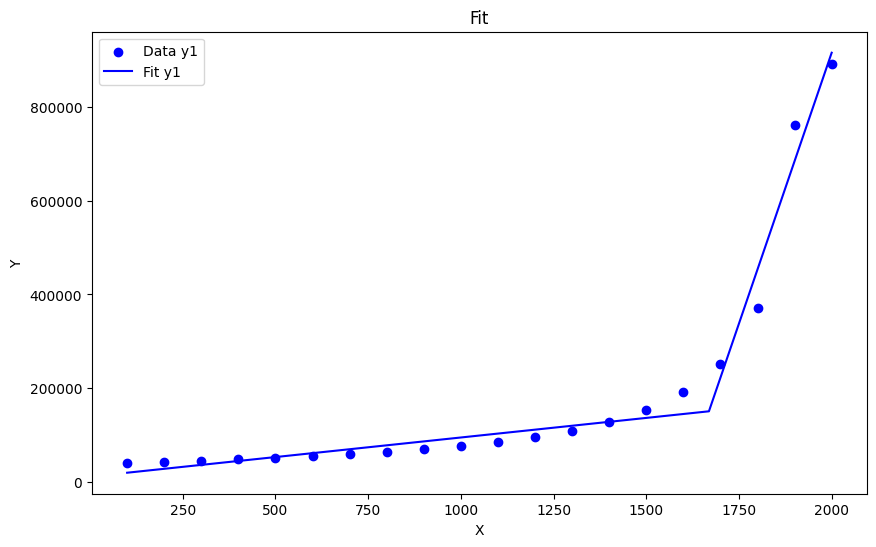

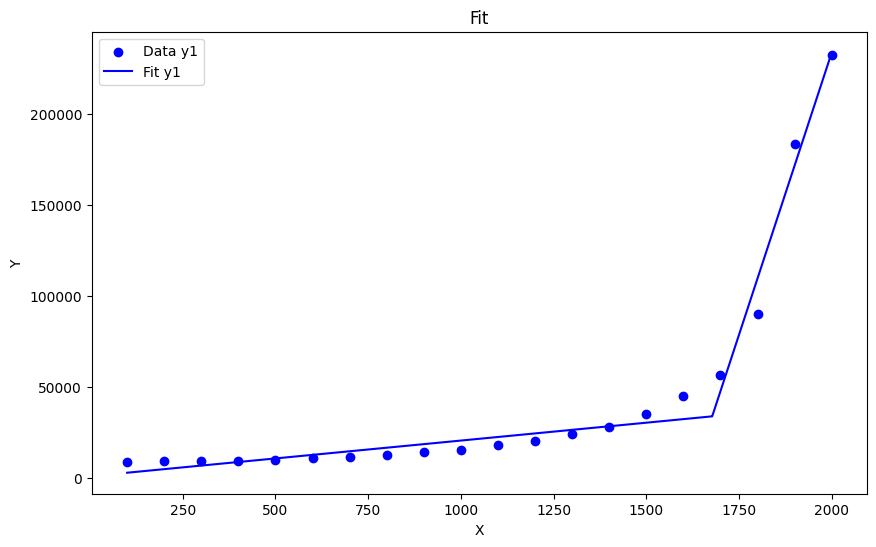

40000 350 4000 149 2.355
45000 410 4500 174 2.354
50000 470 5000 200 2.353
55000 529 5500 225 2.352
60000 589 6000 251 2.351
65000 649 6500 276 2.351
70000 709 7000 302 2.35
75000 769 7500 327 2.35
80000 828 8000 352 2.35
85000 888 8500 378 2.35
90000 948 9000 403 2.349
95000 1008 9500 429 2.349
100000 1068 10000 454 2.349
105000 1127 10500 480 2.349
110000 1187 11000 505 2.349
115000 1247 11500 531 2.349
120000 1307 12000 556 2.348
125000 1366 12500 582 2.348
130000 1426 13000 607 2.348


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pwlf
from scipy.optimize import fsolve


def plot(data):
    n_points = len(data["rps"])
    x = np.array(data["rps"][:n_points])
    y1 = np.array(data["fcfs"][:n_points])
    # y2 = np.array(data["masa"][:n_points])

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y1, color="blue", label="Data y1")
    # plt.scatter(x, y2, color="green", label="Data y2")

    fit = pwlf.PiecewiseLinFit(x, y1)
    fit.fit(2)
    x_hat = np.linspace(min(x), max(x), num=10000)
    y_hat = fit.predict(x_hat)
    plt.plot(x_hat, y_hat, color="blue", label="Fit y1")

    plt.title("Fit")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.show()

    return fit


def solve(p, target):
    return fsolve(lambda x: p(x) - target, 1000)


e2e_fit = plot(e2e_data)
svc_fit = plot(svc_data)

slos = [
    40000,
    45000,
    50000,
    55000,
    60000,
    65000,
    70000,
    75000,
    80000,
    85000,
    90000,
    95000,
    100000,
    105000,
    110000,
    115000,
    120000,
    125000,
    130000,
]
for slo in slos:
    x1 = solve(e2e_fit.predict, slo)[0]
    x2 = solve(svc_fit.predict, slo / 10)[0]
    print(
        round(slo),
        round(x1),
        round(slo / 10),
        round(x2),
        round(x1 / x2, 3),
    )